## STEP 1: Import libraries.   

In [71]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier



pd.set_option("display.max_columns", None)

## STEP 2: Load the dataset

In [2]:
# Load the dataset
financial_data = pd.read_excel(r"C:\Users\hp\Desktop\Data Science & Analytics (LuxDevHQ)\AUGUST\week19_ml_project\data\raw\finaccess2024_datasprint.xlsx")


In [3]:
financial_data

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20866,Wajir,Rural,Female,36-45,8,"""None """,Married/Living with partner,6600,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,One correct,2,Awareness,Without Disability
20867,Nairobi City,Urban,Female,18-25,4,"""Some secondary""",Married/Living with partner,10000,Usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,No,No,Worsened,Two correct,3,Affordability,Without Disability
20868,Embu,Rural,Male,Above 55,6,"""Some primary """,Widowed,6000,Non-usage,Non-usage,Non-usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,Yes,No,No,Stayed the same,None correct,4,NaN,Without Disability
20869,Taita-Taveta,Urban,Female,26-35,7,"""Primary completed""",Single/Never Married,13000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,Yes,No,No,No,Stayed the same,All correct,6,Affordability,Without Disability


## STEP 3: Checking the overview of the dataset

In [4]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))



In [5]:
basic_checks(financial_data)

----------------------------------- Duplicates -----------------------------------
5
----------------------------------- Shape -----------------------------------
(20871, 28)
----------------------------------- Missing Values -----------------------------------
county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score          

,count,mean,std,min,25%,50%,75%,max
household_size,20871.0,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
monthly_income,20871.0,9702.774280,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
prodsum1,20871.0,3.936563,3.227992,0.0,1.0,3.0,6.0,22.0


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
county,20871,47,Meru,637
location_type,20871,2,Rural,13549
Sex,20871,2,Female,12326
Age,20871,6,26-35,5361
education_level,20871,13,"""Secondary completed """,4113
marital_status,20871,6,Married/Living with partner,11432
Savings_formal,20871,2,Non-usage,11635
Savings_informal,20871,2,Non-usage,16031
Loan_formal,20871,2,Non-usage,12340
Loan_informal,20871,2,Non-usage,12604


None


__Categorical Entries__

In [6]:
categorical_columns = financial_data.select_dtypes(include = ["str", "object"]).columns.to_list()

In [7]:
print(categorical_columns)

for col in categorical_columns:
    print("-"*35, col.upper(), "-"*35)
    print(financial_data[col].unique())
    print("Count: ", financial_data[col].nunique())

['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status', 'fl_score', 'barriers_bank', 'has_disability']
----------------------------------- COUNTY -----------------------------------
<StringArray>
[        'Garissa',           'Busia',          'Kiambu',        'Murang'a',
          'Kilifi',            'Meru',          'Kisumu',         'Baringo',
          'Isiolo',            'Embu',         'Mombasa', 'Elgeyo-Marakwet',
         'Homabay',          'Migori',           'Siaya',      'West Pokot',
           'Nyeri',           'Bomet',         'Makueni',     'Uasin Gishu',
         'Bungoma',          'Nakuru',        'Kakamega',           'Kwale',
           'Kitui',         'M

__Check for Outliers__

['household_size', 'monthly_income', 'prodsum1']


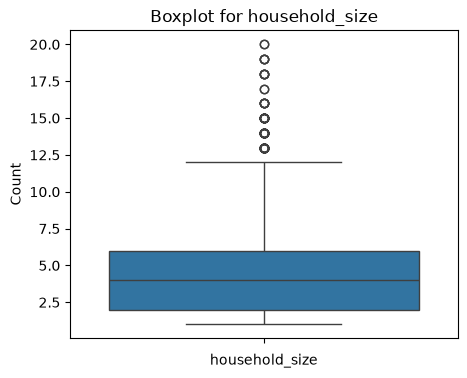

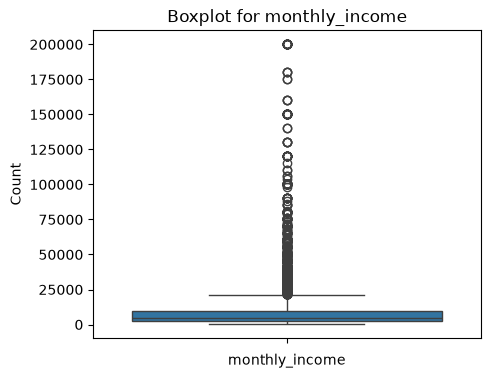

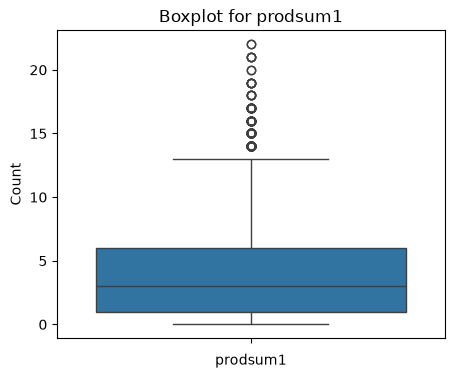

In [8]:
num_cols = financial_data.select_dtypes(include=["int", "float"]).columns.to_list()
print(num_cols)

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(data = financial_data, y= col)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# STEP 3: Data Cleaning

__Drop Duplicates__

In [9]:
# Drop duplicates
financial_data.drop_duplicates(inplace = True)

# Check if the have been dropped
financial_data.duplicated().sum()


np.int64(0)

__Cleaning Categorical Entries__

__Remove "Completed technical training after secondary school", "Some Technical Training and replace with "Technical Training__

In [10]:
# Strip all trailing and preceding spaces from all the categorical columns
for col in categorical_columns:
    financial_data[col] = financial_data[col].astype(str).str.strip()


In [11]:
# Remove 'Completed technical training after secondary school', 'Some technical training after secondary school' replace with 'Technical Training'
mapping = {'Completed technical training after secondary school':'Technical training',
           'Some technical training after secondary school':'Technical incomplete',
           '"Secondary completed "':'Secondary',
           '"Primary completed"':'Primary',
           '"Some primary "':'Primary incomplete',
           '"None "':'None',
           '"Some secondary"':'Secondary incomplete',
           '"University completed "':'University',
           'Some university':'University incomplete',
           '"Refused to Answer (DO NOT READ OUT)"':'',
           '"Other (Specify) "':'',
           '95':''
           }


financial_data = financial_data.replace(mapping)

In [12]:
(financial_data['education_level'].value_counts()/len(financial_data))*100

education_level
Secondary                         19.711492
Primary                           18.944695
Primary incomplete                17.880763
None                              14.727308
Secondary incomplete              13.088278
Technical training                 6.810122
University                         4.734976
Technical incomplete               2.401035
University incomplete              1.658200
                                   0.033547
"Don't know (DO NOT READ OUT)"     0.009585
Name: count, dtype: float64

In [13]:
print(financial_data["education_level"].unique())
print(financial_data["education_level"].isna().sum())

<StringArray>
[            'Technical training',                           'None',
                        'Primary',           'Secondary incomplete',
           'Technical incomplete',                      'Secondary',
             'Primary incomplete',                     'University',
                               '',          'University incomplete',
 '"Don't know (DO NOT READ OUT)"']
Length: 11, dtype: str
0


In [14]:
financial_data = financial_data[~financial_data["education_level"].str.contains("DO NOT READ OUT",na=False)]

In [15]:
print(financial_data["education_level"].unique())

<StringArray>
[   'Technical training',                  'None',               'Primary',
  'Secondary incomplete',  'Technical incomplete',             'Secondary',
    'Primary incomplete',            'University',                      '',
 'University incomplete']
Length: 10, dtype: str


In [16]:
financial_data.drop(financial_data[financial_data["education_level"]== ""].index, inplace=True)

In [17]:
print(financial_data["education_level"].unique())

<StringArray>
[   'Technical training',                  'None',               'Primary',
  'Secondary incomplete',  'Technical incomplete',             'Secondary',
    'Primary incomplete',            'University', 'University incomplete']
Length: 9, dtype: str


 __Cleaning Marital Status Categories__

In [18]:
(financial_data["marital_status"].value_counts()/len(financial_data)) *100

marital_status
Married/Living with partner           54.772978
Single/Never Married                  27.640600
Widowed                               10.706238
Divorced/separated                     6.837033
Don't know   (DO NOT READ OUT)         0.023973
Refused to Answer(DO NOT READ OUT)     0.019178
Name: count, dtype: float64

__Drop The Following Categories__

Don't know   (DO NOT READ OUT)

Refused to Answer(DO NOT READ OUT) 

In [19]:
mapping = {"Don't know   (DO NOT READ OUT)": '',
           "Refused to Answer(DO NOT READ OUT)": ''}

financial_data['marital_status'] = financial_data['marital_status'].replace(mapping)


In [20]:
financial_data["marital_status"].unique()

<StringArray>
['Married/Living with partner',          'Divorced/separated',
        'Single/Never Married',                     'Widowed',
                            '']
Length: 5, dtype: str

In [21]:
financial_data.drop(financial_data[financial_data["marital_status"]== ""].index, inplace=True)

In [22]:
financial_data.columns

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

__Cleaning barriers mobile money category__

In [23]:
mapping = {"0": "None"}

In [24]:
financial_data["barriers_mobile_money"] = financial_data["barriers_mobile_money"].replace(mapping)

In [25]:
financial_data["barriers_mobile_money"].unique()

<StringArray>
[                 'None',           'Eligibility',       'Phone ownership',
          'Line blocked',                 'Other',         'Affordability',
 'Relevance/Suitability',             'Awareness',       'Service quality',
                 'Trust']
Length: 10, dtype: str

__Handling Missing Values__

In [26]:
financial_data.isna().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5730
has_disability              0
dtype: int64

In [27]:
# Check percentage of missing data
(financial_data.isna().sum() / len(financial_data))*100

county                    0.000000
location_type             0.000000
Sex                       0.000000
Age                       0.000000
household_size            0.000000
education_level           0.000000
marital_status            0.000000
monthly_income            0.000000
Savings_formal            0.000000
Savings_informal          0.000000
Loan_formal               0.000000
Loan_informal             0.000000
defaulted                 0.000000
formal_service_use        0.000000
mobile_money_access       0.000000
barriers_mobile_money     0.000000
mobile_ownership_1        0.000000
experienced_shock         0.000000
nfhi_11                   0.000000
nfhi_12                   0.000000
nfhi_13                   0.000000
accessto_13k_1month       0.000000
not_difficult             0.000000
financial_status          0.000000
fl_score                  0.000000
prodsum1                  0.000000
barriers_bank            27.484651
has_disability            0.000000
dtype: float64

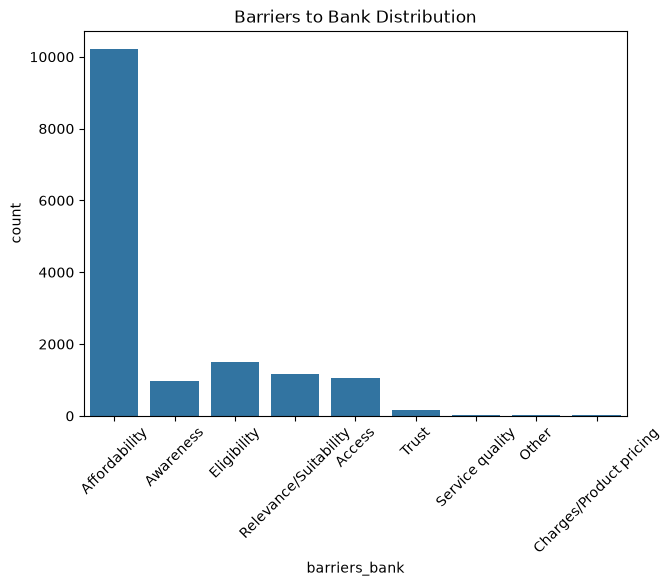

In [28]:
# Check the distribution of barriers_bank
plt.figure(figsize=(7,5))
sns.countplot(financial_data, x="barriers_bank")
plt.title("Barriers to Bank Distribution")
plt.xlabel("barriers_bank")
plt.xticks(rotation = 45)
plt.show()

In [29]:
# Filling nulls
barriers_bank_mode = financial_data["barriers_bank"].mode()[0]
print(barriers_bank_mode)

Affordability


In [30]:
financial_data = financial_data.fillna(value={"barriers_bank": barriers_bank_mode})

In [31]:
# Check percentage of missing data
(financial_data.isna().sum() / len(financial_data))*100

county                   0.0
location_type            0.0
Sex                      0.0
Age                      0.0
household_size           0.0
education_level          0.0
marital_status           0.0
monthly_income           0.0
Savings_formal           0.0
Savings_informal         0.0
Loan_formal              0.0
Loan_informal            0.0
defaulted                0.0
formal_service_use       0.0
mobile_money_access      0.0
barriers_mobile_money    0.0
mobile_ownership_1       0.0
experienced_shock        0.0
nfhi_11                  0.0
nfhi_12                  0.0
nfhi_13                  0.0
accessto_13k_1month      0.0
not_difficult            0.0
financial_status         0.0
fl_score                 0.0
prodsum1                 0.0
barriers_bank            0.0
has_disability           0.0
dtype: float64

## Step 4: EDA and Hypothesis Test

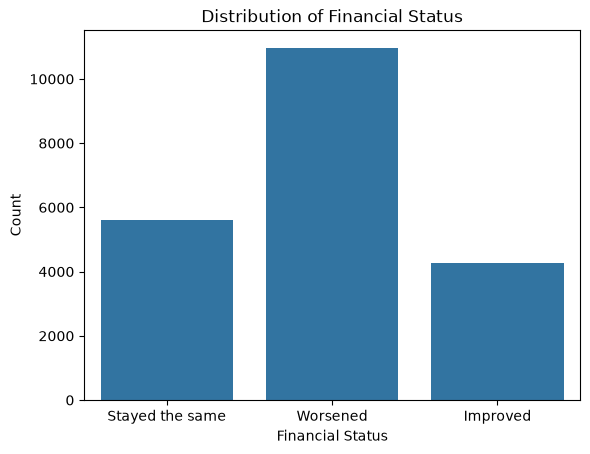

In [32]:
# Check the distribution of the column in question

financial_data["financial_status"].unique()

plt.Figure(figsize=(10,5))

sns.countplot(data = financial_data, x="financial_status")
plt.title("Distribution of Financial Status")
plt.xlabel("Financial Status")
plt.ylabel("Count")

plt.show()

__Financial Status vs Age__

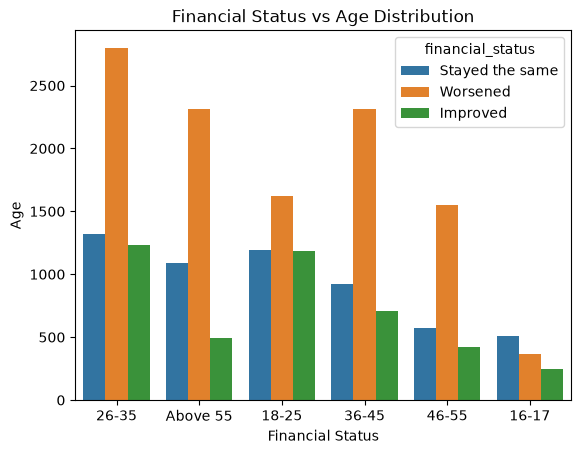

In [33]:
plt.Figure(figsize=(10,5))

sns.countplot(financial_data, x= "Age", hue= "financial_status")
plt.title("Financial Status vs Age Distribution")
plt.xlabel("Financial Status")
plt.ylabel("Age")
plt.show()

__Financial Status vs Education__

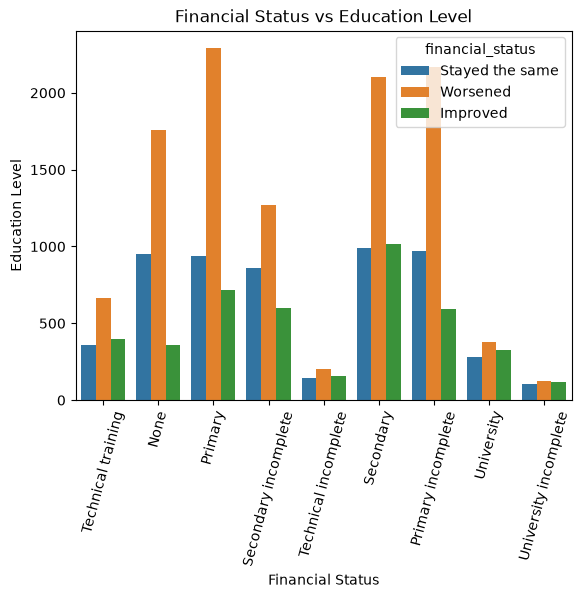

In [34]:
plt.Figure(figsize=(10,5))

sns.countplot(financial_data, x= "education_level", hue= "financial_status")
plt.title("Financial Status vs Education Level")
plt.xlabel("Financial Status")
plt.ylabel("Education Level")
plt.xticks(rotation = 75)
plt.show()

__Financial Status vs Disability__

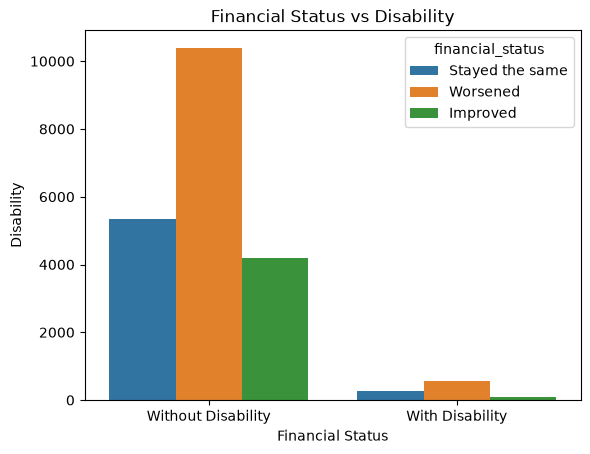

In [35]:
plt.Figure(figsize=(10,5))

sns.countplot(financial_data, x= "has_disability", hue= "financial_status")
plt.title("Financial Status vs Disability")
plt.xlabel("Financial Status")
plt.ylabel("Disability")
plt.show()

__Monthly Income vs Saving Type(formal)__

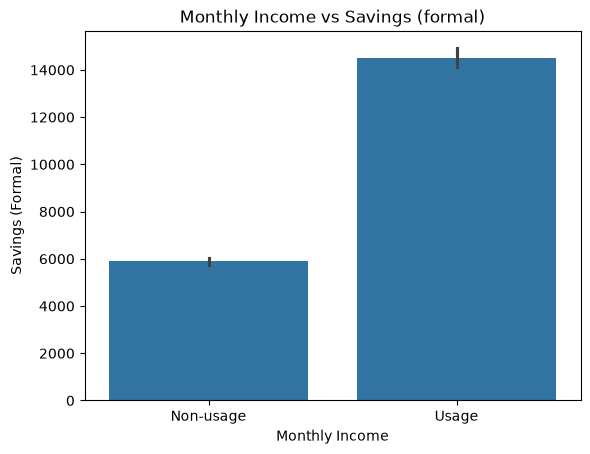

In [36]:
plt.Figure(figsize=(10,5))

sns.barplot(financial_data, x= "Savings_formal", y= "monthly_income")
plt.title("Monthly Income vs Savings (formal)")
plt.xlabel("Monthly Income")
plt.ylabel("Savings (Formal)")
plt.show()

In [37]:
financial_data.columns

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

#### Hypothesis Test
__Categorical column vs Target(categorical)__

In [38]:
!pip install scipy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
categorical_columns

['county',
 'location_type',
 'Sex',
 'Age',
 'education_level',
 'marital_status',
 'Savings_formal',
 'Savings_informal',
 'Loan_formal',
 'Loan_informal',
 'defaulted',
 'formal_service_use',
 'mobile_money_access',
 'barriers_mobile_money',
 'mobile_ownership_1',
 'experienced_shock',
 'nfhi_11',
 'nfhi_12',
 'nfhi_13',
 'accessto_13k_1month',
 'not_difficult',
 'financial_status',
 'fl_score',
 'barriers_bank',
 'has_disability']

In [40]:
categorical_columns.remove("financial_status")

In [41]:
for column in categorical_columns:
    print("="*40, column.upper(), "="*40)
    h0 = f"There is no association between {column} and financial status"
    h1 = f"There is an association between {column} and financial status"

    contingency_table = pd.crosstab(financial_data[column], financial_data["financial_status"])
    chi2_stats, p, dof, expected = chi2_contingency(contingency_table)
    if p <= 0.05:
        print(f"Reject the null hypothesis: {h0}")
    else:
        print(f"Fail to reject the null hypothesis: {h0}")

======================================== COUNTY ========================================
Reject the null hypothesis: There is no association between county and financial status
======================================== LOCATION_TYPE ========================================
Reject the null hypothesis: There is no association between location_type and financial status
======================================== SEX ========================================
Reject the null hypothesis: There is no association between Sex and financial status
======================================== AGE ========================================
Reject the null hypothesis: There is no association between Age and financial status
======================================== EDUCATION_LEVEL ========================================
Reject the null hypothesis: There is no association between education_level and financial status
======================================== MARITAL_STATUS =======================================

__Numerical column vs Target(Categorical)__

In [42]:
# Create numeric columns
numeric_columns = financial_data.select_dtypes(include= ["int", "float"]).columns.to_list()

In [43]:
numeric_columns

['household_size', 'monthly_income', 'prodsum1']

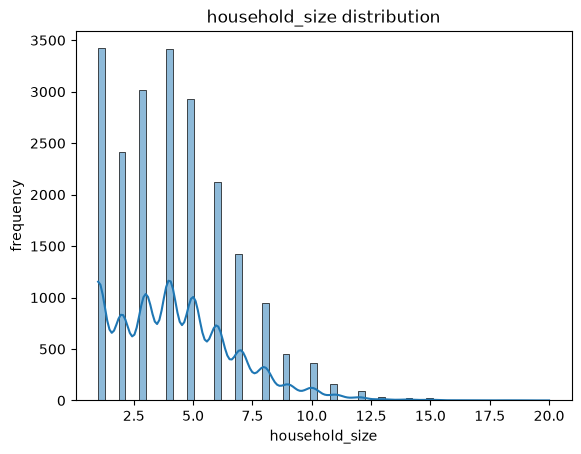

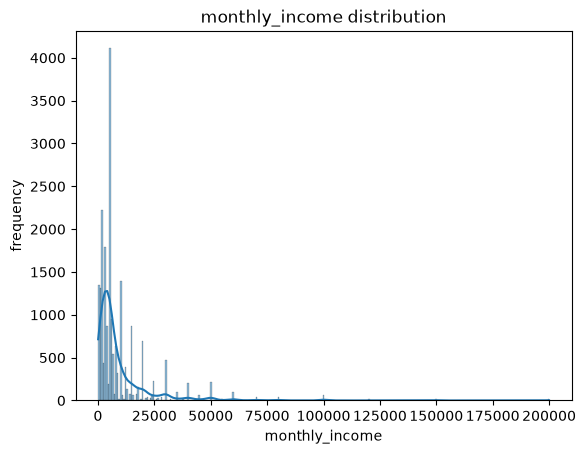

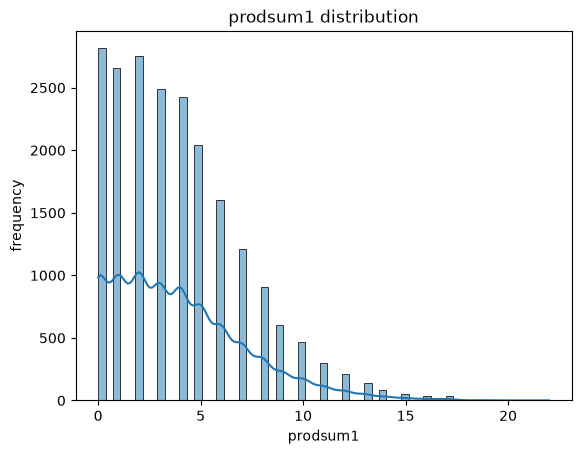

In [44]:
# Checking the distribution of numeric columns

for column in numeric_columns:
    plt.Figure(figsize=(10,5))
    sns.histplot(financial_data[column], kde=True)
    plt.title(f"{column} distribution")
    plt.xlabel(column)
    plt.ylabel("frequency")
    plt.show()

In [45]:
# Check the variance to determine which test to use
financial_data.groupby("financial_status")["prodsum1"].var()

financial_status
Improved           12.176858
Stayed the same     9.802104
Worsened            9.739629
Name: prodsum1, dtype: float64

__Kruskal Wallis Test__

In [46]:
for column in numeric_columns:
    print("="*40, column.upper(), "="*40)
    h0 = f"There is no difference in the distribution of {column} across financial status"
    h1 = f"There is atleast one difference in the distribution of {column} across financial status"

    groups = [group[column].values for name, group in financial_data.groupby('financial_status')]

    stat, p_value = kruskal(*groups)
    if p_value <= 0.05:
        print(f"Reject the null hypothesis {h0}")
    else:
        print(f"Fail to reject the null hypothesis {h1}")

======================================== HOUSEHOLD_SIZE ========================================
Reject the null hypothesis There is no difference in the distribution of household_size across financial status
======================================== MONTHLY_INCOME ========================================
Reject the null hypothesis There is no difference in the distribution of monthly_income across financial status
======================================== PRODSUM1 ========================================
Reject the null hypothesis There is no difference in the distribution of prodsum1 across financial status


__Numerical columns vs Numerical__

In [47]:
correlation = financial_data[numeric_columns].corr(method = "spearman")
correlation

,household_size,monthly_income,prodsum1
household_size,1.000000,-0.116456,-0.156941
monthly_income,-0.116456,1.000000,0.433303
prodsum1,-0.156941,0.433303,1.000000


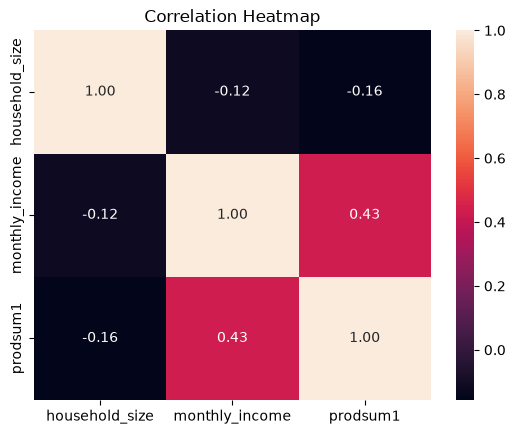

In [48]:
plt.Figure(figsize=(10,5))

sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Step 5: Splitting Features and Target

In [49]:
financial_data.columns

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

In [50]:
X = financial_data.drop(columns= ["financial_status"])
y = financial_data["financial_status"]

In [51]:
print(X.shape, y.shape)

(20848, 27) (20848,)


__Test and Train Test__

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 42, stratify=y )

__Preprocessing (Encoding anf Scaling)__

In [53]:
X_train.columns

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score',
       'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

In [54]:
cat_cols = X_train.select_dtypes(include = ["str", "object"]).columns.to_list()

cat_cols.remove("Age")

In [55]:
# One Hot encoding categorical columns

X_train = pd.get_dummies(X_train, columns= cat_cols, dtype="int", drop_first=True)

In [56]:
X_train.head()

,Age,household_size,monthly_income,prodsum1,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,county_Homabay,county_Isiolo,county_Kajiado,county_Kakamega,county_Kericho,county_Kiambu,county_Kilifi,county_Kirinyaga,county_Kisii,county_Kisumu,county_Kitui,county_Kwale,county_Laikipia,county_Lamu,county_Machakos,county_Makueni,county_Mandera,county_Marsabit,county_Meru,county_Migori,county_Mombasa,county_Murang'a,county_Nairobi City,county_Nakuru,county_Nandi,county_Narok,county_Nyamira,county_Nyandarua,county_Nyeri,county_Samburu,county_Siaya,county_Taita-Taveta,county_Tana River,county_Tharaka-Nithi,county_Trans Nzoia,county_Turkana,county_Uasin Gishu,county_Vihiga,county_Wajir,county_West Pokot,location_type_Urban,Sex_Male,education_level_Primary,education_level_Primary incomplete,education_level_Secondary,education_level_Secondary incomplete,education_level_Technical incomplete,education_level_Technical training,education_level_University,education_level_University incomplete,marital_status_Married/Living with partner,marital_status_Single/Never Married,marital_status_Widowed,Savings_formal_Usage,Savings_informal_Usage,Loan_formal_Usage,Loan_informal_Usage,defaulted_Yes,formal_service_use_Usage,mobile_money_access_Yes,barriers_mobile_money_Awareness,barriers_mobile_money_Eligibility,barriers_mobile_money_Line blocked,barriers_mobile_money_None,barriers_mobile_money_Other,barriers_mobile_money_Phone ownership,barriers_mobile_money_Relevance/Suitability,barriers_mobile_money_Service quality,barriers_mobile_money_Trust,mobile_ownership_1_Yes,experienced_shock_Yes,nfhi_11_Yes,nfhi_12_Yes,nfhi_13_Yes,accessto_13k_1month_Yes,not_difficult_Yes,fl_score_None correct,fl_score_One correct,fl_score_Two correct,barriers_bank_Affordability,barriers_bank_Awareness,barriers_bank_Charges/Product pricing,barriers_bank_Eligibility,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability
5414,26-35,6,5000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
18159,18-25,4,8000,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
16306,18-25,2,2000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
15784,Above 55,5,5000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
13482,16-17,4,5000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1


In [57]:
# X_test
X_test = pd.get_dummies(X_test, columns= cat_cols, dtype="int", drop_first=True)

In [58]:
X_test.head()

,Age,household_size,monthly_income,prodsum1,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,county_Homabay,county_Isiolo,county_Kajiado,county_Kakamega,county_Kericho,county_Kiambu,county_Kilifi,county_Kirinyaga,county_Kisii,county_Kisumu,county_Kitui,county_Kwale,county_Laikipia,county_Lamu,county_Machakos,county_Makueni,county_Mandera,county_Marsabit,county_Meru,county_Migori,county_Mombasa,county_Murang'a,county_Nairobi City,county_Nakuru,county_Nandi,county_Narok,county_Nyamira,county_Nyandarua,county_Nyeri,county_Samburu,county_Siaya,county_Taita-Taveta,county_Tana River,county_Tharaka-Nithi,county_Trans Nzoia,county_Turkana,county_Uasin Gishu,county_Vihiga,county_Wajir,county_West Pokot,location_type_Urban,Sex_Male,education_level_Primary,education_level_Primary incomplete,education_level_Secondary,education_level_Secondary incomplete,education_level_Technical incomplete,education_level_Technical training,education_level_University,education_level_University incomplete,marital_status_Married/Living with partner,marital_status_Single/Never Married,marital_status_Widowed,Savings_formal_Usage,Savings_informal_Usage,Loan_formal_Usage,Loan_informal_Usage,defaulted_Yes,formal_service_use_Usage,mobile_money_access_Yes,barriers_mobile_money_Awareness,barriers_mobile_money_Eligibility,barriers_mobile_money_Line blocked,barriers_mobile_money_None,barriers_mobile_money_Other,barriers_mobile_money_Phone ownership,barriers_mobile_money_Relevance/Suitability,barriers_mobile_money_Service quality,barriers_mobile_money_Trust,mobile_ownership_1_Yes,experienced_shock_Yes,nfhi_11_Yes,nfhi_12_Yes,nfhi_13_Yes,accessto_13k_1month_Yes,not_difficult_Yes,fl_score_None correct,fl_score_One correct,fl_score_Two correct,barriers_bank_Affordability,barriers_bank_Awareness,barriers_bank_Charges/Product pricing,barriers_bank_Eligibility,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability
720,36-45,1,1000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1
1002,36-45,3,60000,11,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1
18703,Above 55,8,3500,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,1
14845,18-25,5,5000,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
6366,26-35,3,5000,6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1


In [59]:
financial_data["Age"].unique()

<StringArray>
['26-35', 'Above 55', '18-25', '36-45', '46-55', '16-17']
Length: 6, dtype: str

In [60]:
# Ordinal encoding Age column
age_order = ["16-17","18-25", "26-35","36-45","46-55","Above 55" ]

encoder = OrdinalEncoder(categories=[age_order])

# X_train 
X_train[["Age"]] = encoder.fit_transform(X_train[["Age"]])

# X_test
X_test[["Age"]] = encoder.transform(X_test[["Age"]])

In [61]:
# Encoding the target column
# Train target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [62]:
# Scaling
num_cols = financial_data.select_dtypes(include = ["int", "float"]).columns.to_list()

In [63]:
scaler = RobustScaler()
# X_train
X_train[num_cols]= scaler.fit_transform(X_train[num_cols])

# X_test
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [64]:
X_train.head()

,Age,household_size,monthly_income,prodsum1,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,county_Homabay,county_Isiolo,county_Kajiado,county_Kakamega,county_Kericho,county_Kiambu,county_Kilifi,county_Kirinyaga,county_Kisii,county_Kisumu,county_Kitui,county_Kwale,county_Laikipia,county_Lamu,county_Machakos,county_Makueni,county_Mandera,county_Marsabit,county_Meru,county_Migori,county_Mombasa,county_Murang'a,county_Nairobi City,county_Nakuru,county_Nandi,county_Narok,county_Nyamira,county_Nyandarua,county_Nyeri,county_Samburu,county_Siaya,county_Taita-Taveta,county_Tana River,county_Tharaka-Nithi,county_Trans Nzoia,county_Turkana,county_Uasin Gishu,county_Vihiga,county_Wajir,county_West Pokot,location_type_Urban,Sex_Male,education_level_Primary,education_level_Primary incomplete,education_level_Secondary,education_level_Secondary incomplete,education_level_Technical incomplete,education_level_Technical training,education_level_University,education_level_University incomplete,marital_status_Married/Living with partner,marital_status_Single/Never Married,marital_status_Widowed,Savings_formal_Usage,Savings_informal_Usage,Loan_formal_Usage,Loan_informal_Usage,defaulted_Yes,formal_service_use_Usage,mobile_money_access_Yes,barriers_mobile_money_Awareness,barriers_mobile_money_Eligibility,barriers_mobile_money_Line blocked,barriers_mobile_money_None,barriers_mobile_money_Other,barriers_mobile_money_Phone ownership,barriers_mobile_money_Relevance/Suitability,barriers_mobile_money_Service quality,barriers_mobile_money_Trust,mobile_ownership_1_Yes,experienced_shock_Yes,nfhi_11_Yes,nfhi_12_Yes,nfhi_13_Yes,accessto_13k_1month_Yes,not_difficult_Yes,fl_score_None correct,fl_score_One correct,fl_score_Two correct,barriers_bank_Affordability,barriers_bank_Awareness,barriers_bank_Charges/Product pricing,barriers_bank_Eligibility,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability
5414,2.0,0.50,0.0,-0.4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1
18159,1.0,0.00,0.4,-0.4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
16306,1.0,-0.50,-0.4,-0.4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
15784,5.0,0.25,0.0,-0.4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
13482,0.0,0.00,0.0,-0.6,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1


### Training Various ML Models

__Logistic Regression__

In [65]:
# Instantiate the model
logistic_model = LogisticRegression(max_iter= 1000)

In [66]:
# Training the model
logistic_model.fit(X_train, y_train_encoded)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [67]:
# Make predictions
y_pred = logistic_model.predict(X_test)


In [68]:
# Evaluation
print("Classification Report for Logistic Regression: ")
print(classification_report(y_pred, y_test_encoded, target_names= le.classes_))

Classification Report for Logistic Regression: 
                 precision    recall  f1-score   support

       Improved       0.29      0.45      0.35       818
Stayed the same       0.22      0.47      0.30       798
       Worsened       0.86      0.61      0.71      4639

       accuracy                           0.57      6255
      macro avg       0.46      0.51      0.46      6255
   weighted avg       0.70      0.57      0.61      6255



In [69]:
len(X_test)

6255

__KNN Model__

In [72]:
# Instantiate the model
knn_model = KNeighborsClassifier(n_neighbors= 5, metric= "minkowski") 

In [73]:
# Fit the model
knn_model.fit(X_train, y_train_encoded)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [74]:
# Make predictions
knn_pred = knn_model.predict(X_test)

In [78]:
# Evaluating the model

print("Classification Report for KNN Model: ", classification_report(knn_pred, y_test_encoded, target_names= le.classes_))

Classification Report for KNN Model:                   precision    recall  f1-score   support

       Improved       0.36      0.34      0.35      1364
Stayed the same       0.32      0.36      0.34      1515
       Worsened       0.65      0.64      0.64      3376

       accuracy                           0.50      6255
      macro avg       0.45      0.44      0.44      6255
   weighted avg       0.51      0.50      0.51      6255

